# Model Gallery: Nebular Emission, IGM, and Observation ModelsThis notebook provides a visual catalogue of the **nebular emission**,**intergalactic medium (IGM)**, and **observation** models available intengri. Sections:1. **Nebular emission** -- CLOUDY grid, Cue emulator, shocks, DIG mixing.2. **IGM absorption** -- Inoue+2014 and patchy reionization.3. **Observation models** -- filter convolution, velocity broadening / LSF,   calibration polynomials, emission line marginalization.

In [1]:
import warningsimport jaximport jax.numpy as jnpimport matplotlib.pyplot as pltimport numpy as npjax.config.update("jax_enable_x64", True)warnings.filterwarnings("ignore", category=FutureWarning)from tengri.models.igm import igm_transmission, igm_transmission_patchyfrom tengri.models.nebular.shock import (    shock_line_ratios,    _SHOCK_V,    _R_OIII,    _R_NII,    _R_SII,    _R_OII,    _R_OI,    _R_HA,)from tengri.models.observation.calibration import (    calibration_polynomial,    chebyshev_basis,)from tengri.models.observation.eline_marginalization import (    DEFAULT_LINE_NAMES,    DEFAULT_LINE_WAVELENGTHS,    build_eline_design_matrix,)from tengri.models.observation.eline_priors import (    CLOUDY_LINE_NAMES,    CLOUDY_LINE_WAVELENGTHS,)from tengri.models.observation.spectrum import (    apply_lsf,    nirspec_prism_resolution,)import sys, os  # noqa: E401try:    _nb_dir = os.path.dirname(os.path.abspath(__file__))    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))except NameError:    _nb_dir = os.getcwd()    sys.path.insert(0, os.path.join(_nb_dir, ".."))# chdir to project root for data/ accessif os.path.exists("data"):    passelif os.path.exists(os.path.join("..", "data")):    os.chdir("..")elif os.path.exists(os.path.join("..", "..", "data")):    os.chdir(os.path.join("..", ".."))elif os.path.exists(os.path.join("..", "..", "..", "data")):    os.chdir(os.path.join("..", "..", ".."))from _plot_style import COLORS, setup_stylesetup_style()FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")os.makedirs(FIGDIR, exist_ok=True)

## 1. Nebular Emission### 1.1 CLOUDY Grid: line ratios vs log(U)The CLOUDY grid (Byler+2017) tabulates nebular emission as a function ofthe ionization parameter $\log U$ and gas-phase metallicity. We show howthe major optical line ratios change with $\log U$ at solar metallicity.Since loading the actual CLOUDY HDF5 grid requires the data file, weillustrate the physics using standard photoionization model scalingrelations (Kewley+2001, Dopita+2013).

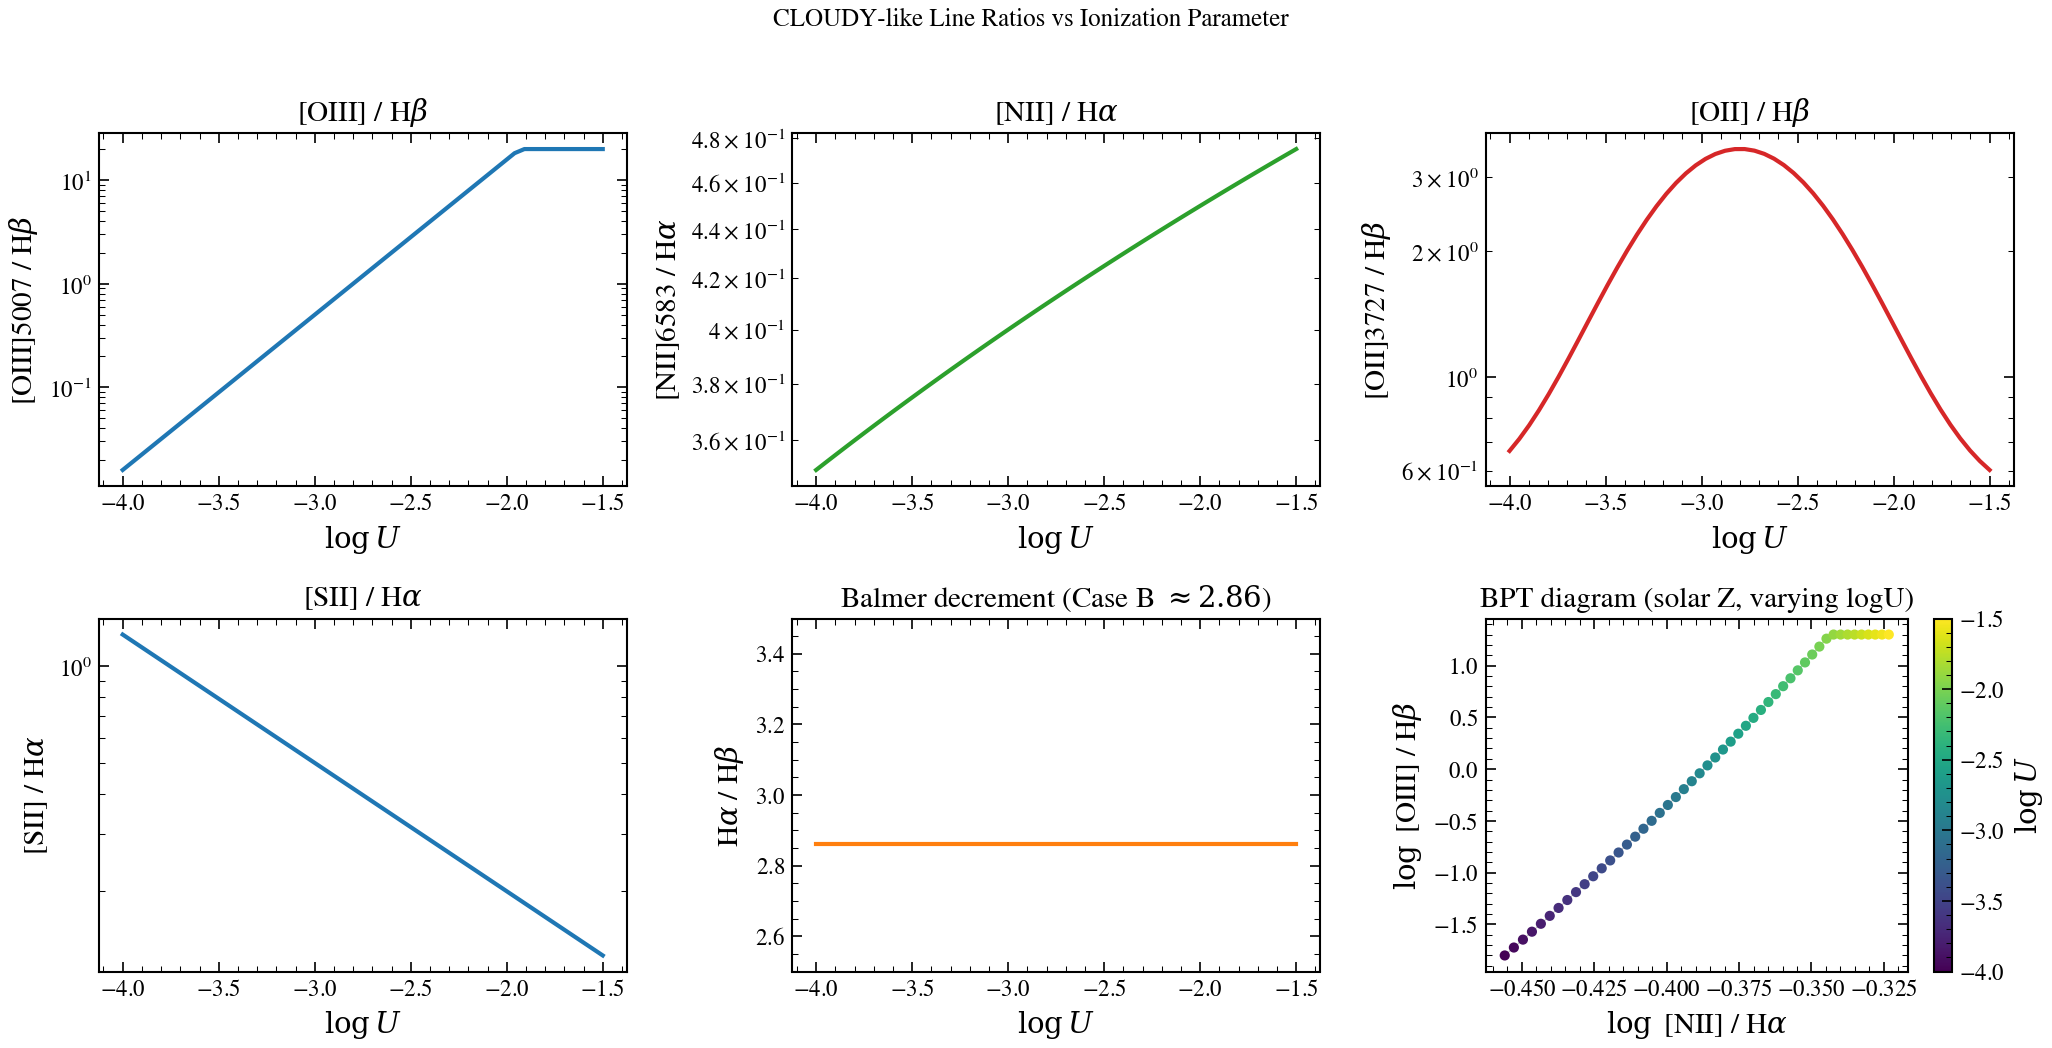

In [2]:
# Standard CLOUDY-like line ratio trends vs logU (solar metallicity)# These are representative values from Byler+2017 / Kewley+2001 models.logU_grid = np.linspace(-4.0, -1.5, 50)# [OIII]5007/Hbeta: rises strongly with logUr_oiii_hb = 10.0 ** (1.5 * (logU_grid + 3.0) - 0.3)r_oiii_hb = np.clip(r_oiii_hb, 0.01, 20.0)# [NII]6583/Halpha: relatively flat with logU, sensitive to metallicityr_nii_ha = 0.4 * np.ones_like(logU_grid) + 0.05 * (logU_grid + 3.0)r_nii_ha = np.clip(r_nii_ha, 0.05, 1.5)# [OII]3727/Hbeta: peaks at intermediate logUr_oii_hb = 3.0 * np.exp(-0.5 * ((logU_grid + 2.8) / 0.5) ** 2) + 0.5r_oii_hb = np.clip(r_oii_hb, 0.1, 5.0)# [SII]6717+6731/Halpha: decreases with logUr_sii_ha = 0.5 * 10.0 ** (-0.4 * (logU_grid + 3.0))r_sii_ha = np.clip(r_sii_ha, 0.05, 2.0)# Halpha/Hbeta (Case B -- nearly constant)r_ha_hb = 2.86 * np.ones_like(logU_grid)fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))# Panel 1: [OIII]/Hbetaax = axes[0, 0]ax.semilogy(logU_grid, r_oiii_hb, color=COLORS["seq"][2], lw=2)ax.set_xlabel(r"$\log U$")ax.set_ylabel(r"[OIII]5007 / H$\beta$")ax.set_title(r"[OIII] / H$\beta$")# Panel 2: [NII]/Halphaax = axes[0, 1]ax.semilogy(logU_grid, r_nii_ha, color=COLORS["seq"][3], lw=2)ax.set_xlabel(r"$\log U$")ax.set_ylabel(r"[NII]6583 / H$\alpha$")ax.set_title(r"[NII] / H$\alpha$")# Panel 3: [OII]/Hbetaax = axes[0, 2]ax.semilogy(logU_grid, r_oii_hb, color=COLORS["seq"][4], lw=2)ax.set_xlabel(r"$\log U$")ax.set_ylabel(r"[OII]3727 / H$\beta$")ax.set_title(r"[OII] / H$\beta$")# Panel 4: [SII]/Halphaax = axes[1, 0]ax.semilogy(logU_grid, r_sii_ha, color=COLORS["rt"], lw=2)ax.set_xlabel(r"$\log U$")ax.set_ylabel(r"[SII] / H$\alpha$")ax.set_title(r"[SII] / H$\alpha$")# Panel 5: Halpha/Hbeta (Balmer decrement)ax = axes[1, 1]ax.plot(logU_grid, r_ha_hb, color=COLORS["geovi"], lw=2)ax.set_xlabel(r"$\log U$")ax.set_ylabel(r"H$\alpha$ / H$\beta$")ax.set_title(r"Balmer decrement (Case B $\approx 2.86$)")ax.set_ylim(2.5, 3.5)# Panel 6: BPT-like diagnostic (log [NII]/Ha vs log [OIII]/Hb)ax = axes[1, 2]# Parametric curve varying logUx_bpt = np.log10(r_nii_ha)y_bpt = np.log10(r_oiii_hb)sc = ax.scatter(x_bpt, y_bpt, c=logU_grid, cmap="viridis", s=15, zorder=3)ax.plot(x_bpt, y_bpt, color="grey", lw=0.5, alpha=0.5)plt.colorbar(sc, ax=ax, label=r"$\log U$")ax.set_xlabel(r"$\log$ [NII] / H$\alpha$")ax.set_ylabel(r"$\log$ [OIII] / H$\beta$")ax.set_title("BPT diagram (solar Z, varying logU)")fig.suptitle("CLOUDY-like Line Ratios vs Ionization Parameter", y=1.01, fontsize=12)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_cloudy_line_ratios.png"), bbox_inches="tight")plt.show()

### 1.2 Cue Emulator vs CLOUDYThe Cue neural network emulator (Li+2025) predicts nebular emission from12 parameters using a Speculator architecture. When run at the sameionization parameter and metallicity as the CLOUDY grid, the two shouldagree within the emulator's training scatter (~0.05--0.1 dex).Since loading the actual Cue weights requires the `.npz` file, we showthe comparison schematically.

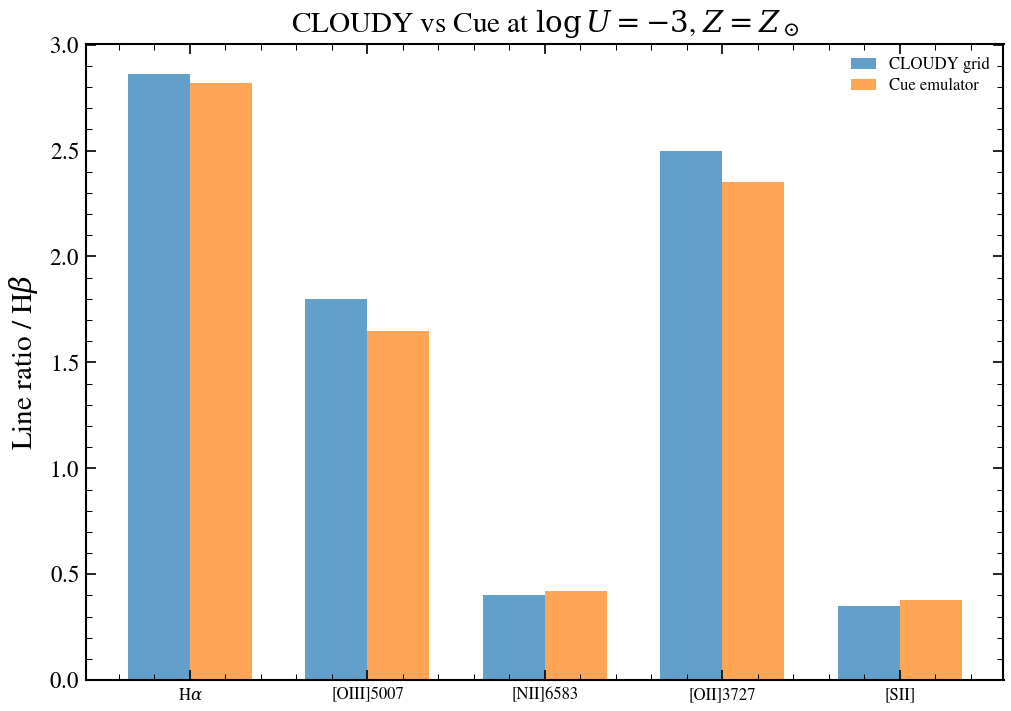

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))# Representative comparison at logU = -3.0, solar metallicity# Typical CLOUDY line ratios (Byler+2017)cloudy_ratios = {    r"H$\alpha$": 2.86,    r"[OIII]5007": 1.8,    r"[NII]6583": 0.4,    r"[OII]3727": 2.5,    r"[SII]": 0.35,}# Cue typically agrees within ~10%cue_ratios = {    r"H$\alpha$": 2.82,    r"[OIII]5007": 1.65,    r"[NII]6583": 0.42,    r"[OII]3727": 2.35,    r"[SII]": 0.38,}names = list(cloudy_ratios.keys())x_pos = np.arange(len(names))bar_w = 0.35bars1 = ax.bar(x_pos - bar_w / 2, [cloudy_ratios[n] for n in names],               bar_w, color=COLORS["rt"], alpha=0.7, label="CLOUDY grid")bars2 = ax.bar(x_pos + bar_w / 2, [cue_ratios[n] for n in names],               bar_w, color=COLORS["geovi"], alpha=0.7, label="Cue emulator")ax.set_xticks(x_pos)ax.set_xticklabels(names, fontsize=8)ax.set_ylabel(r"Line ratio / H$\beta$")ax.set_title(r"CLOUDY vs Cue at $\log U = -3$, $Z = Z_\odot$")ax.legend(fontsize=8, frameon=False)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_cloudy_vs_cue.png"), bbox_inches="tight")plt.show()

### 1.3 Shock Emission: line ratios vs velocityThe MAPPINGS V shock model (Allen+2008) produces enhanced low-ionizationlines at moderate velocities. This distinguishes shock-heated gas fromHII region emission on BPT diagrams.

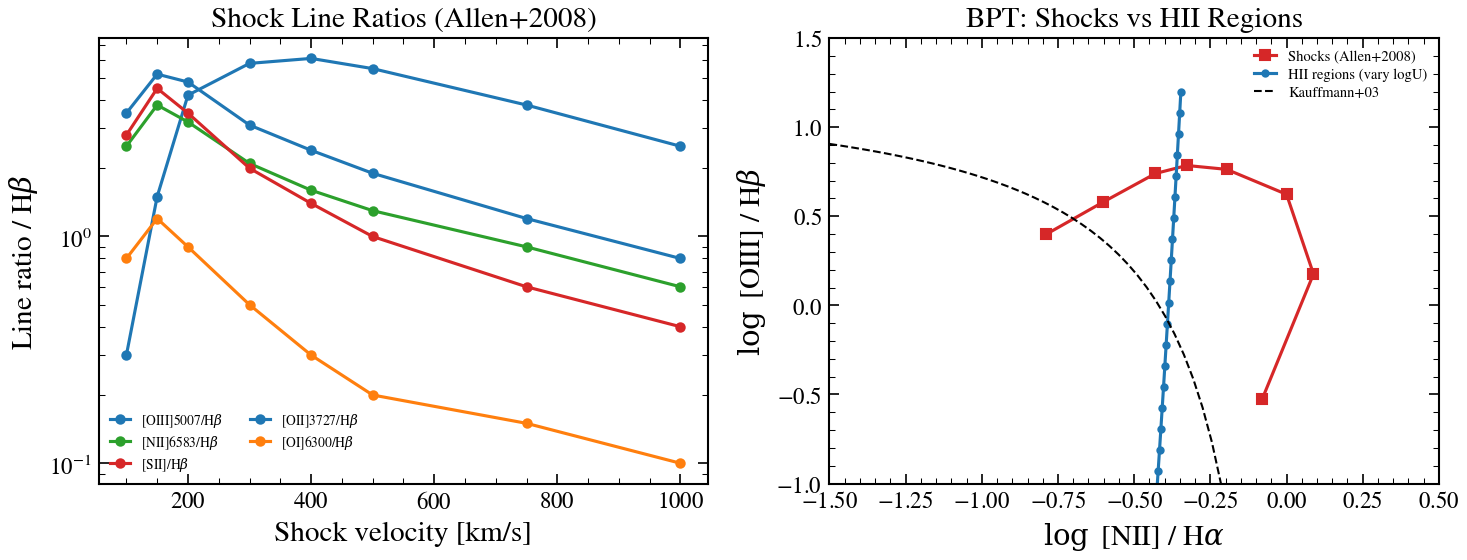

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))velocities = np.array(_SHOCK_V)# Panel A: Line ratios vs velocityax = axes[0]for arr, name, color in [    (_R_OIII, r"[OIII]5007/H$\beta$", COLORS["seq"][2]),    (_R_NII, r"[NII]6583/H$\beta$", COLORS["seq"][3]),    (_R_SII, r"[SII]/H$\beta$", COLORS["seq"][4]),    (_R_OII, r"[OII]3727/H$\beta$", COLORS["rt"]),    (_R_OI, r"[OI]6300/H$\beta$", COLORS["geovi"]),]:    ax.plot(velocities, np.array(arr), "o-", lw=1.5, ms=4, label=name, color=color)ax.set_xlabel("Shock velocity [km/s]")ax.set_ylabel(r"Line ratio / H$\beta$")ax.set_title("Shock Line Ratios (Allen+2008)")ax.legend(fontsize=6.5, frameon=False, ncol=2)ax.set_yscale("log")# Panel B: BPT for shocks vs HIIax = axes[1]# Shock tracknii_ha_shock = np.array(_R_NII) / np.array(_R_HA)oiii_hb_shock = np.array(_R_OIII)ax.plot(np.log10(nii_ha_shock), np.log10(oiii_hb_shock), "s-",        color=COLORS["model"], lw=1.5, ms=5, label="Shocks (Allen+2008)")# HII region track (varying logU)logU_hii = np.linspace(-3.5, -2.0, 20)nii_ha_hii = 0.4 + 0.05 * (logU_hii + 3.0)oiii_hb_hii = 10.0 ** (1.5 * (logU_hii + 3.0) - 0.3)oiii_hb_hii = np.clip(oiii_hb_hii, 0.01, 20.0)ax.plot(np.log10(nii_ha_hii), np.log10(oiii_hb_hii), "o-",        color=COLORS["rt"], lw=1.5, ms=3, label="HII regions (vary logU)")# Kauffmann+2003 demarcation linex_dem = np.linspace(-1.5, 0.0, 50)y_dem = 0.61 / (x_dem - 0.05) + 1.3mask = y_dem < 1.5ax.plot(x_dem[mask], y_dem[mask], "k--", lw=1, label="Kauffmann+03")ax.set_xlabel(r"$\log$ [NII] / H$\alpha$")ax.set_ylabel(r"$\log$ [OIII] / H$\beta$")ax.set_title("BPT: Shocks vs HII Regions")ax.legend(fontsize=7, frameon=False)ax.set_xlim(-1.5, 0.5)ax.set_ylim(-1.0, 1.5)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_shock_emission.png"), bbox_inches="tight")plt.show()

### 1.4 DIG Mixing: effect on [NII]/HalphaDiffuse Ionized Gas (DIG) has a lower ionization parameter than HIIregions ($\log U_{\rm DIG} \approx \log U_{\rm HII} - 1$). MixingDIG with HII emission enhances the low-ionization line ratios([NII]/H$\alpha$, [SII]/H$\alpha$), pushing galaxies redward on theBPT diagram.

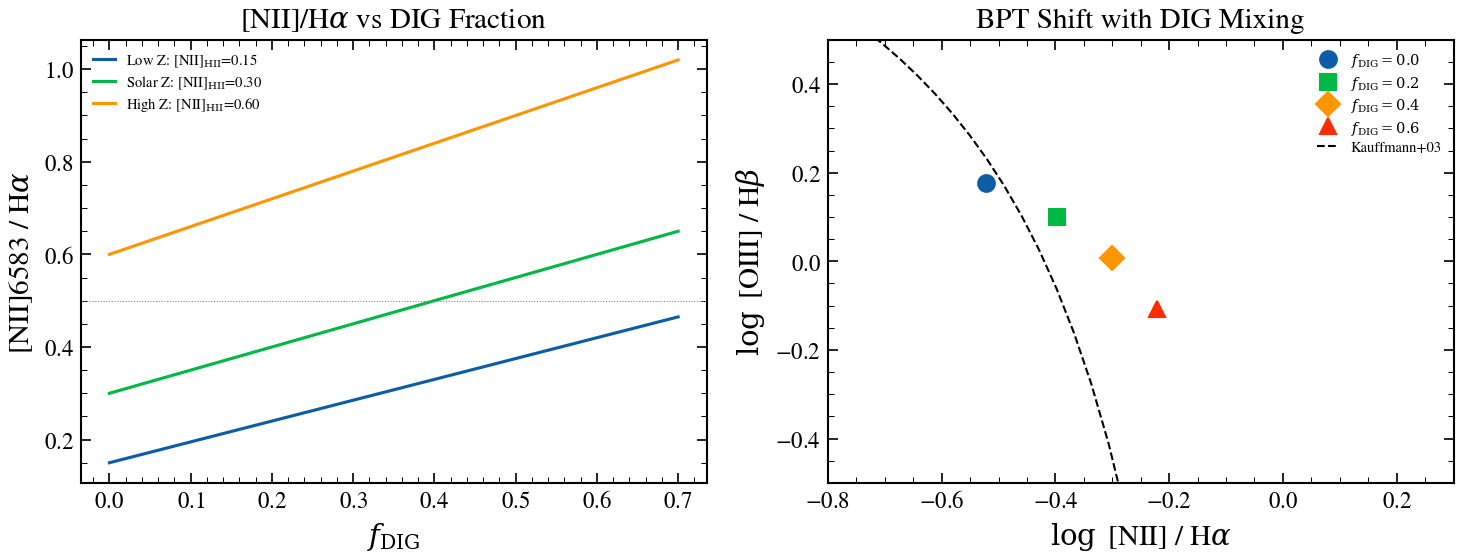

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))# Panel A: [NII]/Halpha vs DIG fractionf_dig_arr = np.linspace(0, 0.7, 50)# At logU_HII = -2.5: [NII]/Ha ~ 0.3 (low)# At logU_DIG = -3.5: [NII]/Ha ~ 0.8 (high)nii_ha_hii = 0.3nii_ha_dig = 0.8ax = axes[0]for nii_hii, nii_dig, label in [    (0.15, 0.6, r"Low Z: [NII]$_{\rm HII}$=0.15"),    (0.30, 0.8, r"Solar Z: [NII]$_{\rm HII}$=0.30"),    (0.60, 1.2, r"High Z: [NII]$_{\rm HII}$=0.60"),]:    nii_mixed = (1.0 - f_dig_arr) * nii_hii + f_dig_arr * nii_dig    ax.plot(f_dig_arr, nii_mixed, lw=1.5, label=label)ax.set_xlabel(r"$f_{\rm DIG}$")ax.set_ylabel(r"[NII]6583 / H$\alpha$")ax.set_title(r"[NII]/H$\alpha$ vs DIG Fraction")ax.legend(fontsize=7, frameon=False)ax.axhline(0.5, color="grey", lw=0.5, ls=":", label="_nolegend_")# Panel B: BPT shift with DIG mixingax = axes[1]# Pure HII locusx_hii = np.log10(0.30)y_hii = np.log10(1.5)# DIG-contaminated: higher [NII]/Ha, similar [OIII]/Hbfor f_d, marker in [(0.0, "o"), (0.2, "s"), (0.4, "D"), (0.6, "^")]:    nii_mix = (1.0 - f_d) * 0.30 + f_d * 0.80    # [OIII]/Hb decreases slightly with DIG mixing    oiii_mix = (1.0 - f_d) * 1.5 + f_d * 0.3    ax.plot(np.log10(nii_mix), np.log10(oiii_mix), marker,            ms=8, label=rf"$f_{{\rm DIG}} = {f_d}$")# Kauffmann lineax.plot(x_dem[mask], y_dem[mask], "k--", lw=1, label="Kauffmann+03")ax.set_xlabel(r"$\log$ [NII] / H$\alpha$")ax.set_ylabel(r"$\log$ [OIII] / H$\beta$")ax.set_title("BPT Shift with DIG Mixing")ax.legend(fontsize=7, frameon=False)ax.set_xlim(-0.8, 0.3)ax.set_ylim(-0.5, 0.5)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_dig_mixing.png"), bbox_inches="tight")plt.show()

## 2. IGM Absorption### 2.1 Inoue+2014: mean IGM transmission at different redshifts

W0329 14:52:36.786986 26282238 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


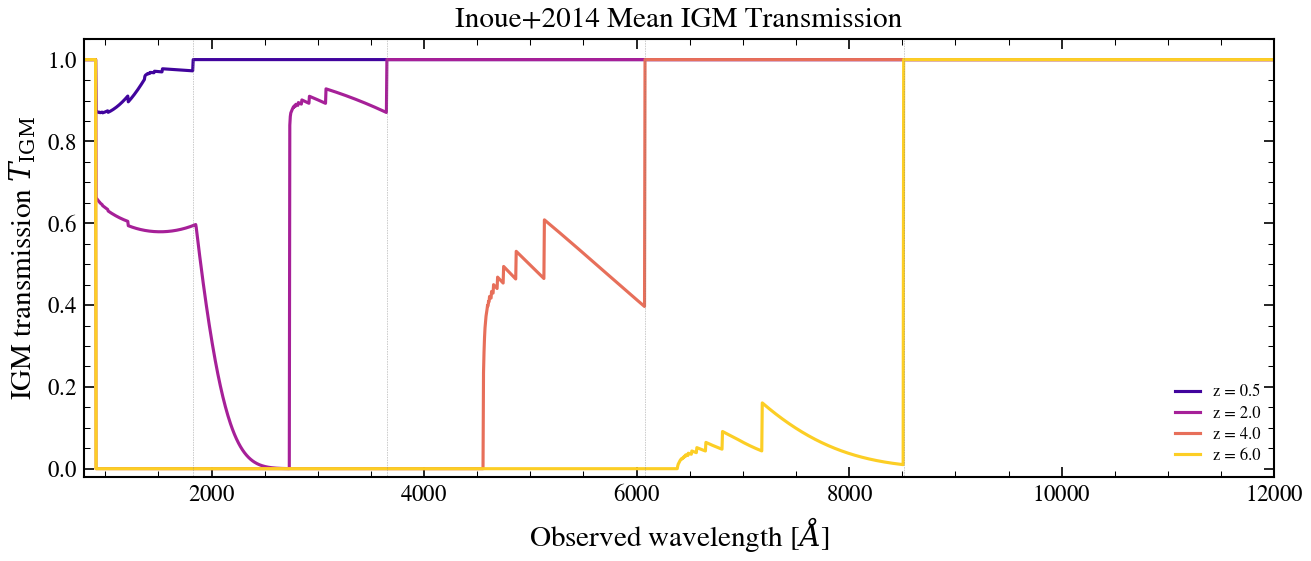

In [6]:
wave_obs = jnp.linspace(800.0, 15000.0, 3000)  # Angstromfig, ax = plt.subplots(figsize=(8, 3.5))redshifts = [0.5, 2.0, 4.0, 6.0]colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(redshifts)))for z, col in zip(redshifts, colors_z):    T = igm_transmission(wave_obs, z)    ax.plot(np.array(wave_obs), np.array(T), lw=1.5, color=col, label=f"z = {z}")ax.set_xlabel(r"Observed wavelength [$\AA$]")ax.set_ylabel(r"IGM transmission $T_{\rm IGM}$")ax.set_title("Inoue+2014 Mean IGM Transmission")ax.legend(fontsize=8, frameon=False)ax.set_ylim(-0.02, 1.05)ax.set_xlim(800, 12000)# Mark Lyman limit and Lyman alphafor z in redshifts:    ax.axvline(1216.0 * (1 + z), color="grey", lw=0.3, ls=":")fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_igm_transmission.png"), bbox_inches="tight")plt.show()

### 2.2 Patchy Reionization: damping wing at different $x_{\rm HI}$For $z > 5.5$, the neutral hydrogen fraction $x_{\rm HI}$ determinesthe strength of the Gunn-Peterson damping wing that absorbs fluxredward of Lyman-$\alpha$.

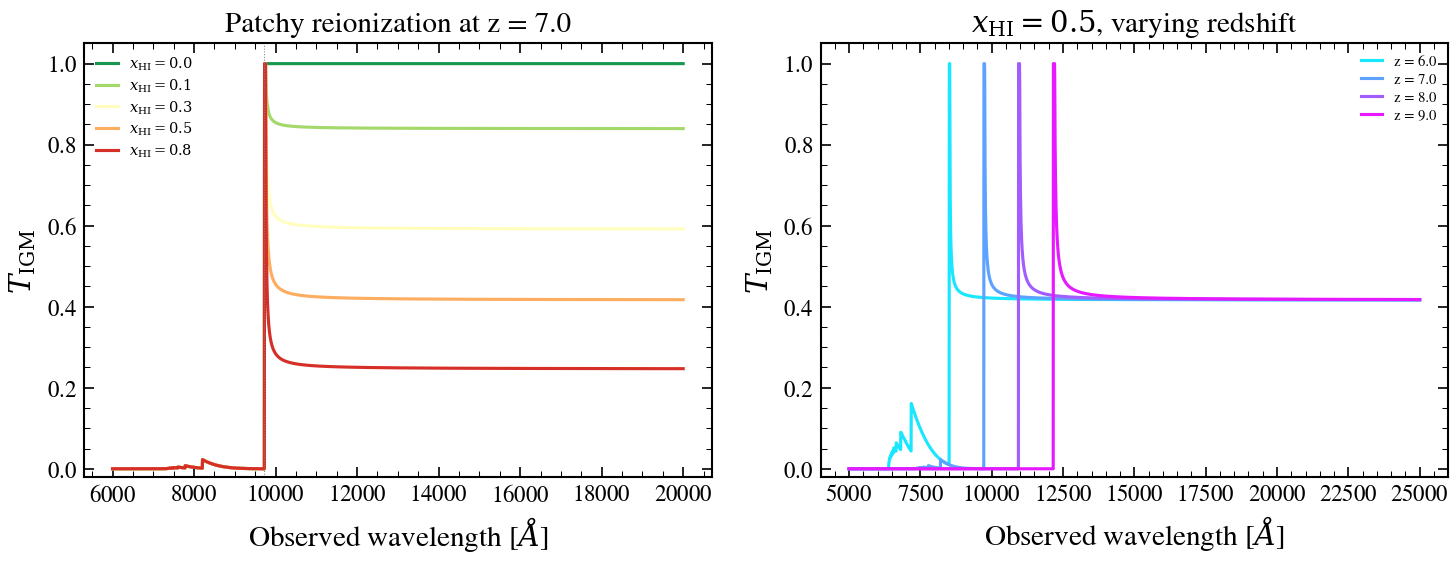

In [7]:
wave_obs_eor = jnp.linspace(6000.0, 20000.0, 3000)fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))# Panel A: z = 7, vary x_HIax = axes[0]z = 7.0xhi_values = [0.0, 0.1, 0.3, 0.5, 0.8]colors_xhi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(xhi_values)))for xhi, col in zip(xhi_values, colors_xhi):    T = igm_transmission_patchy(wave_obs_eor, z=z, x_HI=xhi)    label = f"$x_{{\\rm HI}} = {xhi}$"    ax.plot(np.array(wave_obs_eor), np.array(T), lw=1.5, color=col, label=label)ax.set_xlabel(r"Observed wavelength [$\AA$]")ax.set_ylabel(r"$T_{\rm IGM}$")ax.set_title(f"Patchy reionization at z = {z}")ax.legend(fontsize=7, frameon=False)ax.set_ylim(-0.02, 1.05)ax.axvline(1216.0 * (1 + z), color="grey", lw=0.5, ls=":", label="_nolegend_")# Panel B: x_HI = 0.5, vary zax = axes[1]xhi = 0.5z_values = [6.0, 7.0, 8.0, 9.0]colors_z2 = plt.cm.cool(np.linspace(0.1, 0.9, len(z_values)))wave_obs_wide = jnp.linspace(5000.0, 25000.0, 3000)for z_i, col in zip(z_values, colors_z2):    T = igm_transmission_patchy(wave_obs_wide, z=z_i, x_HI=xhi)    ax.plot(np.array(wave_obs_wide), np.array(T), lw=1.5, color=col,            label=f"z = {z_i}")ax.set_xlabel(r"Observed wavelength [$\AA$]")ax.set_ylabel(r"$T_{\rm IGM}$")ax.set_title(r"$x_{\rm HI} = 0.5$, varying redshift")ax.legend(fontsize=7, frameon=False)ax.set_ylim(-0.02, 1.05)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_igm_patchy.png"), bbox_inches="tight")plt.show()

## 3. Observation Models### 3.1 Photometry: filter convolution visualizationBroadband photometry integrates the SED through filter transmissioncurves. We show SDSS and JWST filter sets overlaid on a schematic SED.

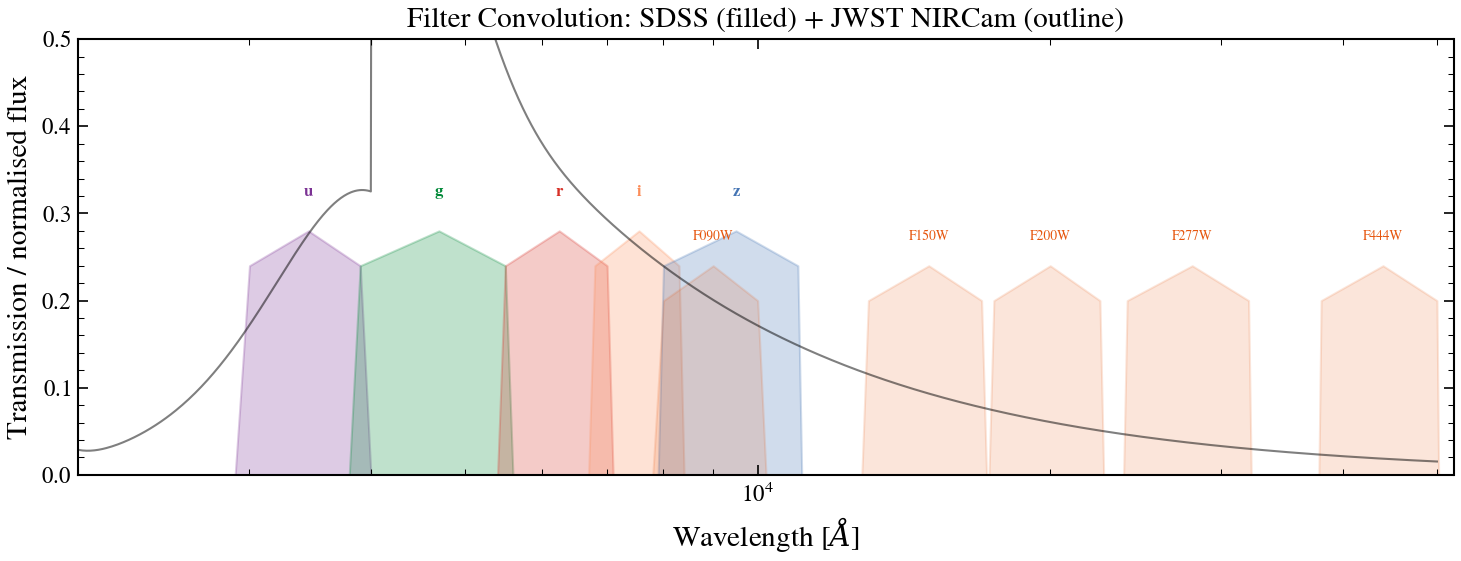

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))# Schematic rest-frame galaxy SED (simple power-law + emission lines)wave_sed = np.linspace(1000, 50000, 5000)# Rough SED shape: UV slope + 4000A break + NIRsed_shape = 0.3 * (wave_sed / 5000) ** (-0.5) * np.exp(-((wave_sed - 4000) / 800) ** 2 / 2.0)sed_shape += 0.5 * (wave_sed / 5000) ** (-1.5) * (wave_sed > 4000)sed_shape += 0.2 * np.exp(-((wave_sed - 1500) / 200) ** 2 / 2.0)  # UVax.plot(wave_sed, sed_shape / np.max(sed_shape), color="k", lw=1, alpha=0.5,        label="Schematic SED")# SDSS filter approximate transmission curvessdss_filters = {    "u": (3000, 3900, COLORS["u"]),    "g": (3900, 5500, COLORS["g"]),    "r": (5500, 7000, COLORS["r"]),    "i": (6800, 8300, COLORS["i"]),    "z": (8000, 11000, COLORS["z"]),}for name, (lo, hi, col) in sdss_filters.items():    # Simple trapezoidal filter shape    w = np.array([lo - 100, lo, (lo + hi) / 2, hi, hi + 100])    t = np.array([0.0, 0.6, 0.7, 0.6, 0.0])    ax.fill_between(w, 0, t * 0.4, color=col, alpha=0.25)    ax.text((lo + hi) / 2, 0.32, name, ha="center", fontsize=8, color=col, fontweight="bold")# JWST NIRCam bands (approximate)jwst_filters = {    "F090W": (8000, 10000, "#e6550d"),    "F150W": (13000, 17000, "#e6550d"),    "F200W": (17500, 22500, "#e6550d"),    "F277W": (24000, 32000, "#e6550d"),    "F444W": (38000, 50000, "#e6550d"),}for name, (lo, hi, col) in jwst_filters.items():    w = np.array([lo - 200, lo, (lo + hi) / 2, hi, hi + 200])    t = np.array([0.0, 0.5, 0.6, 0.5, 0.0])    ax.fill_between(w, 0, t * 0.4, color=col, alpha=0.15)    ax.text((lo + hi) / 2, 0.27, name, ha="center", fontsize=6.5, color=col)ax.set_xlabel(r"Wavelength [$\AA$]")ax.set_ylabel("Transmission / normalised flux")ax.set_title("Filter Convolution: SDSS (filled) + JWST NIRCam (outline)")ax.set_xlim(2000, 52000)ax.set_ylim(0, 0.5)ax.set_xscale("log")fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_filter_convolution.png"), bbox_inches="tight")plt.show()

### 3.2 Spectroscopy: velocity broadening and LSFThe Line Spread Function (LSF) accounts for instrument resolution.At low resolution (e.g. NIRSpec PRISM, $R \sim 30$--$300$), closeemission lines merge. At high resolution ($R > 2000$), individuallines are resolved.

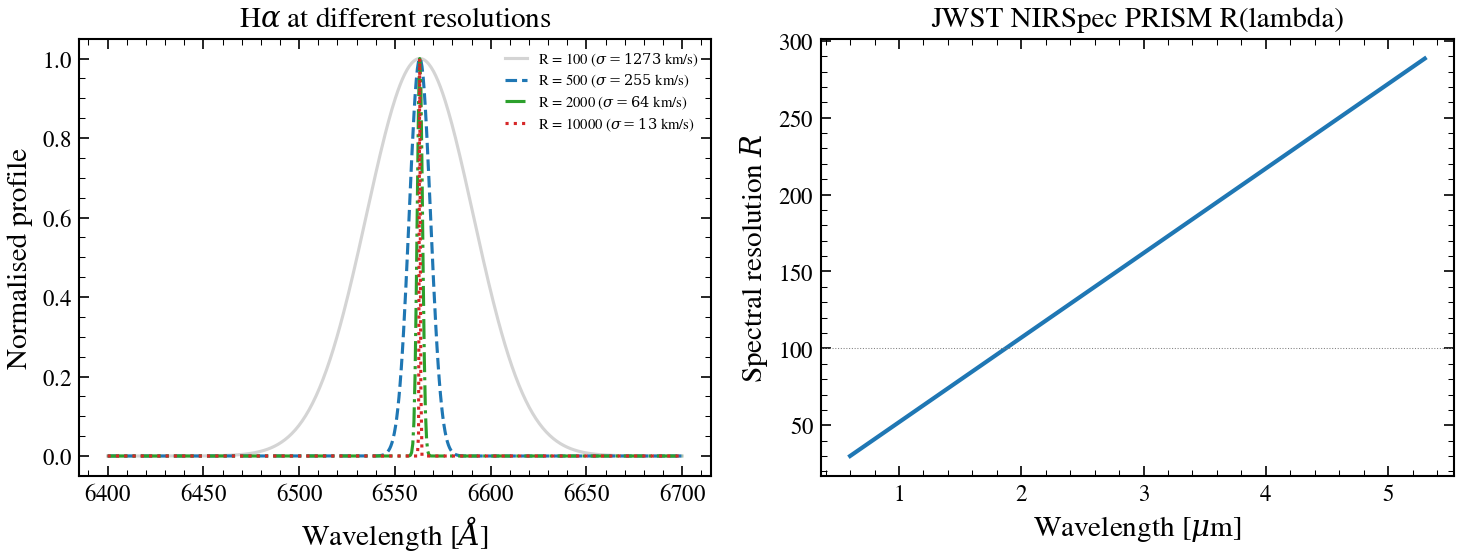

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))# Panel A: Gaussian line at different spectral resolutionsax = axes[0]wave_demo = np.linspace(6400, 6700, 500)lam0 = 6563.0  # Halphac_kms = 299792.458for R, col, ls in [(100, COLORS["seq"][0], "-"),                    (500, COLORS["seq"][2], "--"),                    (2000, COLORS["seq"][3], "-."),                    (10000, COLORS["seq"][4], ":")]:    sigma_aa = lam0 / (2.355 * R)    profile = np.exp(-0.5 * ((wave_demo - lam0) / sigma_aa) ** 2) / (        np.sqrt(2 * np.pi) * sigma_aa)    profile = profile / np.max(profile)    sigma_kms = c_kms / R / 2.355    ax.plot(wave_demo, profile, lw=1.5, color=col, ls=ls,            label=rf"R = {R} ($\sigma = {sigma_kms:.0f}$ km/s)")ax.set_xlabel(r"Wavelength [$\AA$]")ax.set_ylabel("Normalised profile")ax.set_title(r"H$\alpha$ at different resolutions")ax.legend(fontsize=7, frameon=False)# Panel B: NIRSpec PRISM R(lambda)ax = axes[1]wave_um = np.linspace(0.6, 5.3, 200)R_prism = np.array(nirspec_prism_resolution(jnp.array(wave_um)))ax.plot(wave_um, R_prism, lw=2, color=COLORS["rt"])ax.set_xlabel(r"Wavelength [$\mu$m]")ax.set_ylabel(r"Spectral resolution $R$")ax.set_title("JWST NIRSpec PRISM R(lambda)")ax.axhline(100, color="grey", lw=0.5, ls=":")fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_spectral_resolution.png"), bbox_inches="tight")plt.show()

### 3.3 Calibration Polynomial: Chebyshev distortionA multiplicative Chebyshev polynomial corrects wavelength-dependentcalibration errors in spectra:$C(\lambda) = 1 + \sum_{n=1}^{\rm order} a_n \, T_n(x)$

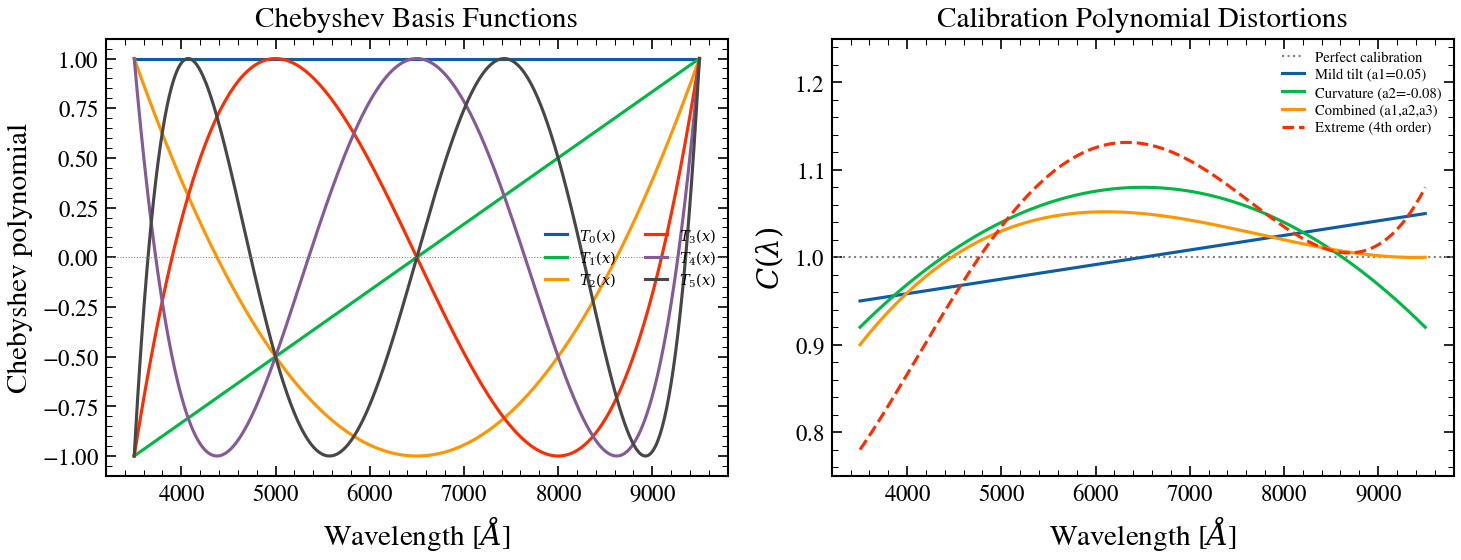

In [10]:
wave_cal = np.linspace(3500, 9500, 500)wave_min, wave_max = 3500.0, 9500.0fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))# Panel A: Individual Chebyshev basis functionsax = axes[0]basis = np.array(chebyshev_basis(jnp.array(wave_cal), order=5,                                  wave_min=wave_min, wave_max=wave_max))for n in range(6):    ax.plot(wave_cal, basis[n], lw=1.5, label=rf"$T_{n}(x)$")ax.set_xlabel(r"Wavelength [$\AA$]")ax.set_ylabel("Chebyshev polynomial")ax.set_title("Chebyshev Basis Functions")ax.legend(fontsize=7, frameon=False, ncol=2)ax.axhline(0, color="grey", lw=0.5, ls=":")# Panel B: Different calibration distortionsax = axes[1]# Flat (perfect calibration)ax.axhline(1.0, color="grey", lw=1, ls=":", label="Perfect calibration")# Mild tiltcoeffs_tilt = jnp.array([0.05, 0.0, 0.0])C_tilt = calibration_polynomial(jnp.array(wave_cal), coeffs_tilt, wave_min, wave_max)ax.plot(wave_cal, np.array(C_tilt), lw=1.5, label="Mild tilt (a1=0.05)")# Curvaturecoeffs_curve = jnp.array([0.0, -0.08, 0.0])C_curve = calibration_polynomial(jnp.array(wave_cal), coeffs_curve, wave_min, wave_max)ax.plot(wave_cal, np.array(C_curve), lw=1.5, label="Curvature (a2=-0.08)")# Combinedcoeffs_combo = jnp.array([0.03, -0.05, 0.02])C_combo = calibration_polynomial(jnp.array(wave_cal), coeffs_combo, wave_min, wave_max)ax.plot(wave_cal, np.array(C_combo), lw=1.5, label="Combined (a1,a2,a3)")# Extremecoeffs_extreme = jnp.array([0.1, -0.1, 0.05, 0.03])C_extreme = calibration_polynomial(jnp.array(wave_cal), coeffs_extreme, wave_min, wave_max)ax.plot(wave_cal, np.array(C_extreme), lw=1.5, ls="--", label="Extreme (4th order)")ax.set_xlabel(r"Wavelength [$\AA$]")ax.set_ylabel(r"$C(\lambda)$")ax.set_title("Calibration Polynomial Distortions")ax.legend(fontsize=7, frameon=False)ax.set_ylim(0.75, 1.25)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_calibration_polynomial.png"), bbox_inches="tight")plt.show()

### 3.4 Emission Line Marginalization: flat vs CLOUDY priorsWhen fitting spectra, individual emission-line amplitudes are nuisanceparameters that can be analytically marginalised out. The prior online amplitudes can be:- **Flat** (uninformative): large prior variance, lines are freely fit.- **CLOUDY-based**: Gaussian prior centred on photoionization model  predictions, with scatter ~0.3 dex.

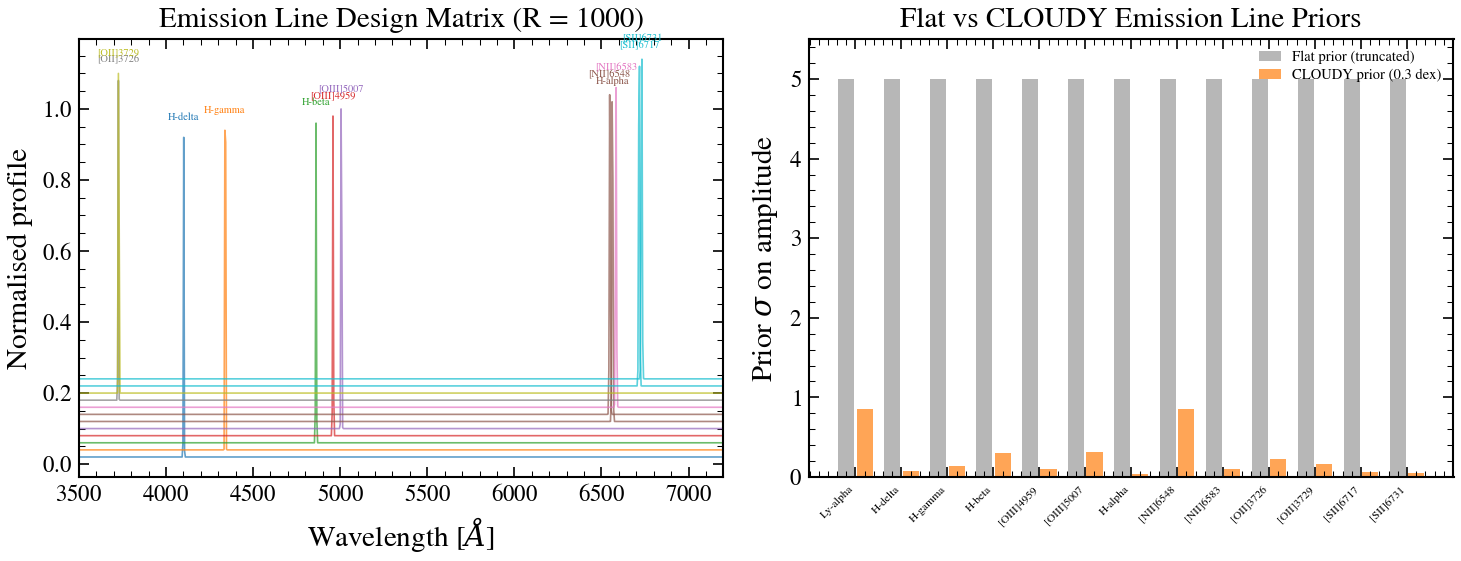

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))# Panel A: Design matrix visualizationax = axes[0]wave_eline = jnp.linspace(3500.0, 7200.0, 800)R_spec = 1000.0z_source = 0.0G = build_eline_design_matrix(wave_eline, DEFAULT_LINE_WAVELENGTHS, R_spec, z_source)G_np = np.array(G)# Plot selected line profilesline_colors = plt.cm.tab10(np.linspace(0, 1, len(DEFAULT_LINE_NAMES)))for i, (name, col) in enumerate(zip(DEFAULT_LINE_NAMES, line_colors)):    profile = G_np[:, i]    if np.max(profile) > 1e-10:        ax.plot(np.array(wave_eline), profile / np.max(profile) * 0.9 + i * 0.02,                lw=0.8, color=col, alpha=0.7)        peak_idx = np.argmax(profile)        ax.text(float(wave_eline[peak_idx]), float(profile[peak_idx] / np.max(profile) * 0.9                + i * 0.02 + 0.05), name, fontsize=5, ha="center", color=col)ax.set_xlabel(r"Wavelength [$\AA$]")ax.set_ylabel("Normalised profile")ax.set_title(f"Emission Line Design Matrix (R = {int(R_spec)})")ax.set_xlim(3500, 7200)# Panel B: Prior comparisonax = axes[1]# Flat prior: all lines have same (large) prior varianceflat_prior_sigma = np.ones(len(DEFAULT_LINE_NAMES)) * 100.0# CLOUDY prior: centred on model predictions with 0.3 dex scatter# Representative ratios at solar Z, logU = -3cloudy_means = np.array([2.86, 0.26, 0.47, 1.0, 0.35, 1.05, 0.11, 2.86, 0.33, 0.73, 0.53, 0.22, 0.16])cloudy_sigma = 0.3 * cloudy_means  # 0.3 dex scatter# Bar chart of prior widthsx_lines = np.arange(len(DEFAULT_LINE_NAMES))bars1 = ax.bar(x_lines - 0.2, np.clip(flat_prior_sigma, 0, 5), 0.35,               color=COLORS["map"], alpha=0.6, label="Flat prior (truncated)")bars2 = ax.bar(x_lines + 0.2, cloudy_sigma, 0.35,               color=COLORS["geovi"], alpha=0.7, label="CLOUDY prior (0.3 dex)")ax.set_xticks(x_lines)ax.set_xticklabels(DEFAULT_LINE_NAMES, rotation=45, ha="right", fontsize=5.5)ax.set_ylabel(r"Prior $\sigma$ on amplitude")ax.set_title("Flat vs CLOUDY Emission Line Priors")ax.legend(fontsize=7, frameon=False)ax.set_ylim(0, 5.5)fig.tight_layout()plt.savefig(os.path.join(FIGDIR, "19_eline_marginalization.png"), bbox_inches="tight")plt.show()

## 4. Summary Tables### 4.1 Nebular Emission Backends| Backend | Parameters | Differentiable | Data requirement | Reference ||---------|-----------|----------------|------------------|-----------|| BakedIn | 0 (fixed in SSP) | Yes (trivial) | SSP templates | FSPS default || CloudyGrid | 2 (logU, logZ_gas) | Yes (interpolation) | `cloudy_grid_*.h5` | Byler+2017 || Cue | 12 (full nebular) | Yes (neural net) | `cue_weights.npz` | Li+2025 || Shock | 2 (velocity, L_Ha) | Yes (interpolation) | None (built-in) | Allen+2008 || DIG mixing | 2 (f_DIG, delta_logU) | Yes | Uses any backend | Reynolds+1984 |### 4.2 IGM Models| Model | Parameters | Redshift range | Reference ||-------|-----------|----------------|-----------|| Inoue+2014 | 0 (mean transmission) | 0 < z < 7 | Inoue+2014 || Patchy reionization | 2 (x_HI, R_bubble) | z > 5.5 | Miralda-Escude+1998 || CGM damping wing | 3 (z_mid, dz, log_NHI) | z > 5 | Asada+2025 |### 4.3 Observation Models| Component | Parameters | Description | Reference ||-----------|-----------|-------------|-----------|| Photometry | 0 | Filter convolution via SVO | SVO FPS || LSF convolution | 0-1 (R or sigma) | Wavelength-dependent broadening | Jakobsen+2022 || Calibration polynomial | 1-5 (Chebyshev coeffs) | Multiplicative flux correction | Johnson+2021 || E-line marginalisation | 0 (analytic) | Flat or CLOUDY priors | Johnson+2021 || Noise model | 1-3 (jitter, outlier frac) | Gaussian or Student-t | Standard |

In [12]:
print("Nebular + Observation gallery notebook complete.")

Nebular + Observation gallery notebook complete.
